## profiliing

In [1]:
import os
import pandas as pd
import numpy as np

DATA_DIR = "./Data"
train_path = os.path.join(DATA_DIR, "train.csv")
test_path = os.path.join(DATA_DIR, "test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("train shape", train_df.shape)
print("test shape", test_df.shape)

display(train_df.head)
display(test_df.head)

train shape (891, 12)
test shape (418, 11)


<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                     

<bound method NDFrame.head of      PassengerId  Pclass                                          Name  \
0            892       3                              Kelly, Mr. James   
1            893       3              Wilkes, Mrs. James (Ellen Needs)   
2            894       2                     Myles, Mr. Thomas Francis   
3            895       3                              Wirz, Mr. Albert   
4            896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)   
..           ...     ...                                           ...   
413         1305       3                            Spector, Mr. Woolf   
414         1306       1                  Oliva y Ocana, Dona. Fermina   
415         1307       3                  Saether, Mr. Simon Sivertsen   
416         1308       3                           Ware, Mr. Frederick   
417         1309       3                      Peter, Master. Michael J   

        Sex   Age  SibSp  Parch              Ticket      Fare Cabin Embarked  
0 

# row type, missing rate, only value

In [2]:
def profile_table(df: pd.DataFrame) -> pd.DataFrame:
    total = len(df)
    mis_cnt = df.isnull().sum()
    mis_rate = mis_cnt / total * 100
    nunique = df.nunique(dropna=True)
    dtypes = df.dtypes.astype(str)

    prof = pd.DataFrame(
        {
            "dtpye": dtypes,
            "nunique": nunique,
            "mis_rate": mis_rate,
            "mis_cnt": mis_cnt,

        }
    ).sort_values(by=["mis_rate", "nunique"], ascending=[False, False])

    example = {}
    for col in df.columns:
        s = df[col].dropna()
        example[col] = s.iloc[0] if len(s) > 0 else np.nan
    prof["example_value"] = pd.Series(example)

    return prof

train_prof = profile_table(train_df)
test_prof  = profile_table(test_df)

display(train_prof)
display(test_prof)

,dtpye,nunique,mis_rate,mis_cnt,example_value
Cabin,object,147,77.104377,687,C85
Age,float64,88,19.865320,177,22.0
Embarked,object,3,0.224467,2,S
PassengerId,int64,891,0.000000,0,1
Name,object,891,0.000000,0,"Braund, Mr. Owen Harris"
Ticket,object,681,0.000000,0,A/5 21171
Fare,float64,248,0.000000,0,7.25
SibSp,int64,7,0.000000,0,1
Parch,int64,7,0.000000,0,0
Pclass,int64,3,0.000000,0,3


,dtpye,nunique,mis_rate,mis_cnt,example_value
Cabin,object,76,78.229665,327,B45
Age,float64,79,20.574163,86,34.5
Fare,float64,169,0.239234,1,7.8292
PassengerId,int64,418,0.000000,0,892
Name,object,418,0.000000,0,"Kelly, Mr. James"
Ticket,object,363,0.000000,0,330911
Parch,int64,8,0.000000,0,0
SibSp,int64,7,0.000000,0,0
Pclass,int64,3,0.000000,0,3
Embarked,object,3,0.000000,0,Q


# abnormal value

In [3]:
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric cols:", num_cols)

display(train_df[num_cols].describe().T)

for col in ["Age", "Fare"]:
    if col in train_df.columns:
        s = train_df[col]
        print(f"\n[{col}] min={s.min()} max={s.max()} missing={s.isna().sum()}")
        display(train_df[[col]].sort_values(col).head(5))
        display(train_df[[col]].sort_values(col).tail(5))


Numeric cols: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



[Age] min=0.42 max=80.0 missing=177


,Age
803,0.42
755,0.67
644,0.75
469,0.75
78,0.83


,Age
859,NaN
863,NaN
868,NaN
878,NaN
888,NaN



[Fare] min=0.0 max=512.3292 missing=0


,Fare
271,0.0
597,0.0
302,0.0
633,0.0
277,0.0


,Fare
438,263.0000
341,263.0000
737,512.3292
258,512.3292
679,512.3292


In [4]:
cat_cols = [c for c in train_df.columns if train_df[c].dtype == "object"]
print("Categorical cols:", cat_cols)

for col in cat_cols:
    vc = train_df[col].value_counts(dropna=False).head(20)
    print(f"\n[{col}] top values (including NaN):")
    display(vc)


Categorical cols: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

[Name] top values (including NaN):


Name
Braund, Mr. Owen Harris                                1
Boulos, Mr. Hanna                                      1
Frolicher-Stehli, Mr. Maxmillian                       1
Gilinski, Mr. Eliezer                                  1
Murdlin, Mr. Joseph                                    1
Rintamaki, Mr. Matti                                   1
Stephenson, Mrs. Walter Bertram (Martha Eustis)        1
Elsbury, Mr. William James                             1
Bourke, Miss. Mary                                     1
Chapman, Mr. John Henry                                1
Van Impe, Mr. Jean Baptiste                            1
Leitch, Miss. Jessie Wills                             1
Johnson, Mr. Alfred                                    1
Duff Gordon, Sir. Cosmo Edmund ("Mr Morgan")           1
Taussig, Miss. Ruth                                    1
Jacobsohn, Mrs. Sidney Samuel (Amy Frances Christy)    1
Slabenoff, Mr. Petco                                   1
Harrington, Mr. Charles H 


[Sex] top values (including NaN):


Sex
male      577
female    314
Name: count, dtype: int64


[Ticket] top values (including NaN):


Ticket
347082          7
CA. 2343        7
1601            7
3101295         6
CA 2144         6
347088          6
S.O.C. 14879    5
382652          5
LINE            4
PC 17757        4
17421           4
349909          4
113760          4
4133            4
113781          4
W./C. 6608      4
2666            4
19950           4
347077          4
C.A. 31921      3
Name: count, dtype: int64


[Cabin] top values (including NaN):


Cabin
NaN                687
C23 C25 C27          4
G6                   4
B96 B98              4
C22 C26              3
D                    3
F33                  3
E101                 3
F2                   3
B20                  2
E67                  2
C125                 2
E24                  2
B49                  2
B77                  2
D35                  2
C78                  2
C93                  2
C65                  2
B57 B59 B63 B66      2
Name: count, dtype: int64


[Embarked] top values (including NaN):


Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [5]:
target_col = "Survived"
if target_col in train_df.columns:
    display(train_df[target_col].value_counts(dropna=False))
    display(train_df[target_col].value_counts(normalize=True).rename("ratio").round(4))


Survived
0    549
1    342
Name: count, dtype: int64

Survived
0    0.6162
1    0.3838
Name: ratio, dtype: float64

## Missing Value Handling

In [6]:
work_df = train_df.copy()

work_df["Age_missing"] = work_df["Age"].isna().astype(int)
work_df["Cabin_missing"] = work_df["Cabin"].isna().astype(int)

- Mode Fill

In [7]:
emb_mode = work_df["Embarked"].mode(dropna=True)[0]
work_df["Embarked"] = work_df["Embarked"].fillna(emb_mode)

print("Embarked mode:", emb_mode)
print("Embarked missing after fill:", work_df["Embarked"].isna().sum())

Embarked mode: S
Embarked missing after fill: 0


- HasCabin

In [8]:
work_df["HasCabin"] = (~work_df["Cabin"].isna()).astype(int)

- Use Sex + Pclass for group median imputation

In [9]:
work_df["Age"] = work_df["Age"].fillna(
    work_df.groupby(["Sex", "Pclass"])["Age"].transform("median")
)

work_df["Age"] = work_df["Age"].fillna(work_df["Age"].median())

print("Age missing after fill:", work_df["Age"].isna().sum())

Age missing after fill: 0


In [10]:
cols_check = ["Age", "Embarked", "Cabin", "Deck", "HasCabin", "Age_missing", "Cabin_missing"]
exist_cols = [c for c in cols_check if c in work_df.columns]
display(work_df[exist_cols].isna().sum())
display(work_df.head())

Age                0
Embarked           0
Cabin            687
HasCabin           0
Age_missing        0
Cabin_missing      0
dtype: int64

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_missing,Cabin_missing,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,0,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,0


## Feature Engineering

- Title Extraction + Merging of Rare Titles

In [11]:
work_df = work_df.copy()

work_df["Title"] = work_df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()

rare_titles = ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev",
               "Sir", "Jonkheer", "Dona", "Mme", "Ms", "Mlle"]

work_df["Title"] = work_df["Title"].replace(rare_titles, "Other")

work_df["Title"] = work_df["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
})
(work_df["Title"].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Other            26
the Countess      1
Name: count, dtype: int64

- family related

In [12]:
work_df["FamilySize"] = work_df["SibSp"] + work_df["Parch"] + 1
work_df["IsAlone"] = (work_df["FamilySize"] == 1).astype(int)

display(work_df[["SibSp", "Parch", "FamilySize", "IsAlone"]].head())

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


- fare per person

In [13]:
work_df["FarePerPerson"] = work_df["Fare"] / work_df["FamilySize"]
display(work_df[["Fare", "FamilySize", "FarePerPerson"]].head())

,Fare,FamilySize,FarePerPerson
0,7.2500,2,3.62500
1,71.2833,2,35.64165
2,7.9250,1,7.92500
3,53.1000,2,26.55000
4,8.0500,1,8.05000


In [14]:
print("Title missing:", work_df["Title"].isna().sum())

Title missing: 0


In [15]:
#print(work_df["FamilySize"].describe())
#print(work_df["IsAlone"].value_counts())
work_df["Title"] = work_df["Title"].replace({"the Countess": "Other"})
print(work_df["Title"].value_counts())
print(work_df[["FamilySize","IsAlone"]].head())
print(work_df["Title"].value_counts())

Title
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64
   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1
Title
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64


## One-Hot, ColumnTransformer

In [16]:
from sklearn.model_selection import train_test_split

y = work_df["Survived"].astype(int)

# 只保留 HasCabin，不保留 Cabin_missing（冗余）
X = work_df.drop(columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin", "Cabin_missing"])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "X_valid:", X_valid.shape)
print("y_train mean:", y_train.mean().round(4), "y_valid mean:", y_valid.mean().round(4))
display(X_train.head())

X_train: (712, 13) X_valid: (179, 13)
y_train mean: 0.3834 y_valid mean: 0.3855


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_missing,HasCabin,Title,FamilySize,IsAlone,FarePerPerson
692,3,male,25.0,0,0,56.4958,S,1,0,Mr,1,1,56.4958
481,2,male,30.0,0,0,0.0000,S,1,0,Mr,1,1,0.0000
527,1,male,40.0,0,0,221.7792,S,1,1,Mr,1,1,221.7792
855,3,female,18.0,0,1,9.3500,S,0,0,Mrs,2,0,4.6750
801,2,female,31.0,1,1,26.2500,S,0,0,Mrs,3,0,8.7500


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
import numpy as np

cat_cols = ["Sex", "Embarked", "Title"]

num_cols = [
    "Pclass", "Age", "SibSp", "Parch",
    "Fare", "FamilySize", "IsAlone",
    "HasCabin", "Age_missing",
    "FarePerPerson",
]

fare_log_pipe = Pipeline(steps=[
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
])

preprocess_linear = ColumnTransformer(
    transformers=[
        ("fare_log", fare_log_pipe, ["Fare"]),                       # 用 log1p(Fare)
        ("num", StandardScaler(), [c for c in num_cols if c != "Fare"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

In [18]:
Xtr = preprocess_linear.fit_transform(X_train)
Xva = preprocess_linear.transform(X_valid)

print("Transformed X_train shape:", Xtr.shape)
print("Transformed X_valid shape:", Xva.shape)

Transformed X_train shape: (712, 20)
Transformed X_valid shape: (179, 20)


In [19]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
)


def eval_binary(model_name, key_hyperparameter, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    p1, r1, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[1],
        average=None,
        zero_division=0,
    )

    p1, r1, f1 = p1[0], r1[0], f1[0]

    print(f"\n=== {model_name} | {key_hyperparameter} ===")
    print("Valid Accuracy:", round(acc, 4))
    print("Precision(1):", round(p1, 4))
    print("Recall(1):", round(r1, 4))
    print("F1(1):", round(f1, 4))
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, digits=4, zero_division=0))

    return {
        "model": model_name,
        "key_hyperparameter": key_hyperparameter,
        "valid_accuracy": acc,
        "precision_1": p1,
        "recall_1": r1,
        "f1_1": f1,
        "cm": cm,
    }

##  Naive Bayes（BernoulliNB + Laplace smoothing，α=1.0 vs 0.01

In [20]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import BernoulliNB

cat_cols = ["Sex", "Embarked", "Title"]
num_cols = [
    "Pclass", "Age", "SibSp", "Parch",
    "Fare", "FamilySize", "IsAlone",
    "HasCabin", "Age_missing",
    "FarePerPerson",
]

num_binner = KBinsDiscretizer(n_bins=8, encode="onehot", strategy="quantile")

preprocess_nb = ColumnTransformer(
    transformers=[
        ("num_bin", num_binner, num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

In [21]:
results = []

for a in [1.0, 0.01]:
    nb = Pipeline(steps=[
        ("preprocess", preprocess_nb),
        ("model", BernoulliNB(alpha=a))
    ])
    nb.fit(X_train, y_train)
    pred_valid = nb.predict(X_valid)
    results.append(eval_binary("BernoulliNB", f"alpha={a}", y_valid, pred_valid))


=== BernoulliNB | alpha=1.0 ===
Valid Accuracy: 0.743
Precision(1): 0.6353
Recall(1): 0.7826
F1(1): 0.7013
Confusion Matrix:
 [[79 31]
 [15 54]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8404    0.7182    0.7745       110
           1     0.6353    0.7826    0.7013        69

    accuracy                         0.7430       179
   macro avg     0.7379    0.7504    0.7379       179
weighted avg     0.7614    0.7430    0.7463       179


=== BernoulliNB | alpha=0.01 ===
Valid Accuracy: 0.743
Precision(1): 0.6353
Recall(1): 0.7826
F1(1): 0.7013
Confusion Matrix:
 [[79 31]
 [15 54]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8404    0.7182    0.7745       110
           1     0.6353    0.7826    0.7013        69

    accuracy                         0.7430       179
   macro avg     0.7379    0.7504    0.7379       179
weighted avg     0.7614    0.7430    0.7463       179



E:\Anaconda\envs\ML\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
E:\Anaconda\envs\ML\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
E:\Anaconda\envs\ML\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
E:\Anaconda\envs\ML\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
E:\Anaconda\envs\ML\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarn

## Linear Regression

In [22]:
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# 与上面一致的列
cat_cols = ["Sex", "Embarked", "Title"]
num_cols = [
    "Pclass", "Age", "SibSp", "Parch",
    "Fare", "FamilySize", "IsAlone",
    "HasCabin", "Age_missing",
    "FarePerPerson",
]

fare_log_pipe = Pipeline(steps=[
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
])

preprocess_linear = ColumnTransformer(
    transformers=[
        ("fare_log", fare_log_pipe, ["Fare"]),                       # log1p(Fare)
        ("num", StandardScaler(), [c for c in num_cols if c != "Fare"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

In [23]:
from sklearn.linear_model import LinearRegression

linreg = Pipeline(steps=[
    ("preprocess", preprocess_linear),
    ("model", LinearRegression())
])

linreg.fit(X_train, y_train)
proba_valid = linreg.predict(X_valid)          # 连续值，当作“概率/分数”
pred_valid = (proba_valid >= 0.5).astype(int)  # 阈值 0.5

results.append(eval_binary("LinearRegression", "threshold=0.5", y_valid, pred_valid))


=== LinearRegression | threshold=0.5 ===
Valid Accuracy: 0.8492
Precision(1): 0.8281
Recall(1): 0.7681
F1(1): 0.797
Confusion Matrix:
 [[99 11]
 [16 53]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8609    0.9000    0.8800       110
           1     0.8281    0.7681    0.7970        69

    accuracy                         0.8492       179
   macro avg     0.8445    0.8341    0.8385       179
weighted avg     0.8482    0.8492    0.8480       179



- Ridge


In [24]:
from sklearn.linear_model import Ridge

for a in [0.1, 1.0, 10.0]:
    ridge = Pipeline(steps=[
        ("preprocess", preprocess_linear),
        ("model", Ridge(alpha=a, random_state=42))
    ])
    ridge.fit(X_train, y_train)
    score_valid = ridge.predict(X_valid)
    pred_valid = (score_valid >= 0.5).astype(int)
    results.append(eval_binary("Ridge", f"alpha={a}", y_valid, pred_valid))


=== Ridge | alpha=0.1 ===
Valid Accuracy: 0.8436
Precision(1): 0.8154
Recall(1): 0.7681
F1(1): 0.791
Confusion Matrix:
 [[98 12]
 [16 53]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8596    0.8909    0.8750       110
           1     0.8154    0.7681    0.7910        69

    accuracy                         0.8436       179
   macro avg     0.8375    0.8295    0.8330       179
weighted avg     0.8426    0.8436    0.8426       179


=== Ridge | alpha=1.0 ===
Valid Accuracy: 0.838
Precision(1): 0.8125
Recall(1): 0.7536
F1(1): 0.782
Confusion Matrix:
 [[98 12]
 [17 52]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8522    0.8909    0.8711       110
           1     0.8125    0.7536    0.7820        69

    accuracy                         0.8380       179
   macro avg     0.8323    0.8223    0.8265       179
weighted avg     0.8369    0.8380    0.8367       179


=== Ridge | alpha=

- LASSON

In [25]:
from sklearn.linear_model import Lasso

for a in [0.001, 0.01, 0.1]:
    lasso = Pipeline(steps=[
        ("preprocess", preprocess_linear),
        ("model", Lasso(alpha=a, max_iter=20000, random_state=42))
    ])
    lasso.fit(X_train, y_train)
    score_valid = lasso.predict(X_valid)
    pred_valid = (score_valid >= 0.5).astype(int)
    results.append(eval_binary("Lasso", f"alpha={a}", y_valid, pred_valid))


=== Lasso | alpha=0.001 ===
Valid Accuracy: 0.8324
Precision(1): 0.8
Recall(1): 0.7536
F1(1): 0.7761
Confusion Matrix:
 [[97 13]
 [17 52]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8509    0.8818    0.8661       110
           1     0.8000    0.7536    0.7761        69

    accuracy                         0.8324       179
   macro avg     0.8254    0.8177    0.8211       179
weighted avg     0.8313    0.8324    0.8314       179


=== Lasso | alpha=0.01 ===
Valid Accuracy: 0.7933
Precision(1): 0.75
Recall(1): 0.6957
F1(1): 0.7218
Confusion Matrix:
 [[94 16]
 [21 48]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8174    0.8545    0.8356       110
           1     0.7500    0.6957    0.7218        69

    accuracy                         0.7933       179
   macro avg     0.7837    0.7751    0.7787       179
weighted avg     0.7914    0.7933    0.7917       179


=== Lasso | alpha

- report

Best hyperparameter per model:


,model,key_hyperparameter,valid_accuracy,precision_1,recall_1,f1_1
rank,,,,,,
1,LinearRegression,threshold=0.5,0.8492,0.8281,0.7681,0.7970
2,Ridge,alpha=0.1,0.8436,0.8154,0.7681,0.7910
3,Lasso,alpha=0.001,0.8324,0.8000,0.7536,0.7761
4,BernoulliNB,alpha=1.0,0.7430,0.6353,0.7826,0.7013


All evaluated settings:


,model,key_hyperparameter,valid_accuracy,precision_1,recall_1,f1_1
0,LinearRegression,threshold=0.5,0.8492,0.8281,0.7681,0.7970
1,Ridge,alpha=0.1,0.8436,0.8154,0.7681,0.7910
2,Ridge,alpha=1.0,0.8380,0.8125,0.7536,0.7820
3,Lasso,alpha=0.001,0.8324,0.8000,0.7536,0.7761
4,Ridge,alpha=10.0,0.8212,0.7846,0.7391,0.7612
5,Lasso,alpha=0.01,0.7933,0.7500,0.6957,0.7218
6,BernoulliNB,alpha=1.0,0.7430,0.6353,0.7826,0.7013
7,BernoulliNB,alpha=0.01,0.7430,0.6353,0.7826,0.7013
8,Lasso,alpha=0.1,0.6816,0.8000,0.2319,0.3596


C:\Users\17619\AppData\Local\Temp\ipykernel_24636\3519240676.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


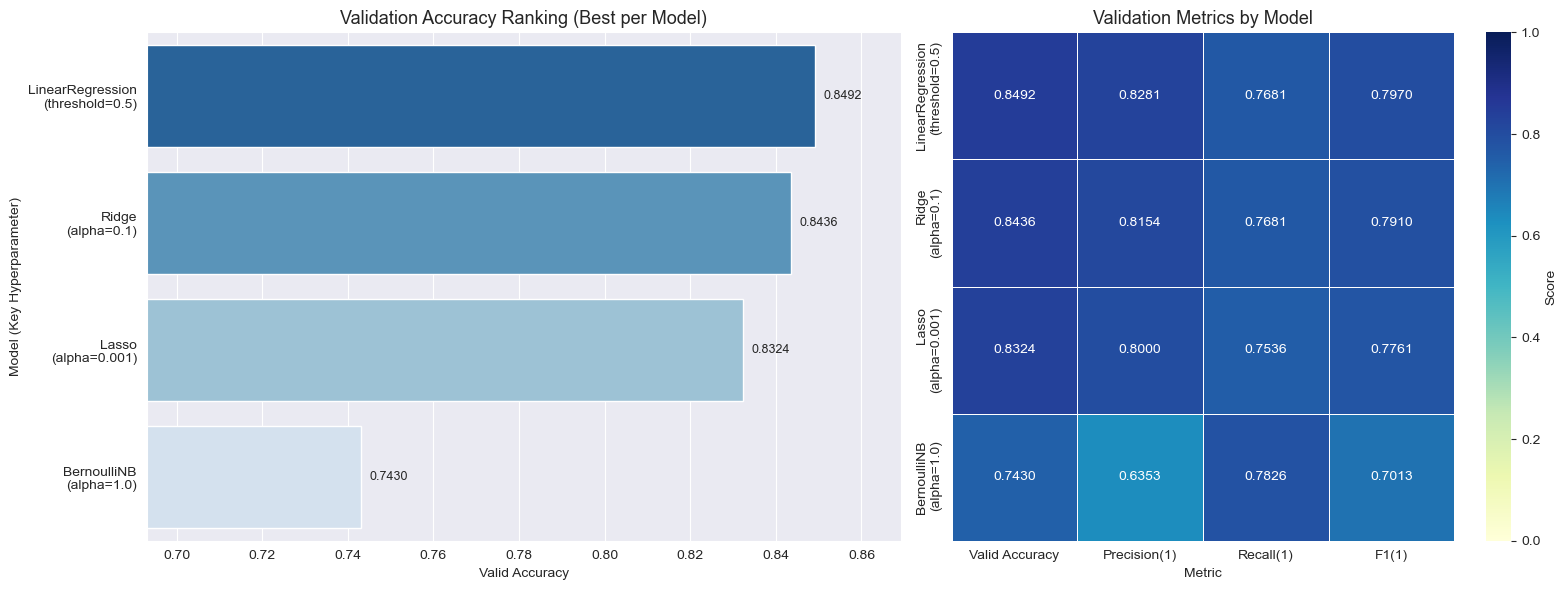

,model,key_hyperparameter,valid_accuracy,precision_1,recall_1,f1_1
rank,,,,,,
1,LinearRegression,threshold=0.5,0.849162,0.828125,0.768116,0.796992
2,Ridge,alpha=0.1,0.843575,0.815385,0.768116,0.791045
3,Lasso,alpha=0.001,0.832402,0.800000,0.753623,0.776119
4,BernoulliNB,alpha=1.0,0.743017,0.635294,0.782609,0.701299


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

all_settings = (
    pd.DataFrame(results)[
        ["model", "key_hyperparameter", "valid_accuracy", "precision_1", "recall_1", "f1_1"]
    ]
    .sort_values(["valid_accuracy", "f1_1"], ascending=False)
    .reset_index(drop=True)
)

summary = (
    all_settings.sort_values(["valid_accuracy", "f1_1"], ascending=False)
    .groupby("model", as_index=False)
    .first()
    .sort_values(["valid_accuracy", "f1_1"], ascending=False)
    .reset_index(drop=True)
)

summary.index = summary.index + 1
summary.index.name = "rank"

print("Best hyperparameter per model:")
display(
    summary.style.format(
        {
            "valid_accuracy": "{:.4f}",
            "precision_1": "{:.4f}",
            "recall_1": "{:.4f}",
            "f1_1": "{:.4f}",
        }
    )
)

print("All evaluated settings:")
display(
    all_settings.style.format(
        {
            "valid_accuracy": "{:.4f}",
            "precision_1": "{:.4f}",
            "recall_1": "{:.4f}",
            "f1_1": "{:.4f}",
        }
    )
)

plot_df = summary.reset_index().copy()
plot_df["model_label"] = plot_df["model"] + "\n(" + plot_df["key_hyperparameter"] + ")"

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.2, 1]})

acc_min = max(0, plot_df["valid_accuracy"].min() - 0.05)
acc_max = min(1, plot_df["valid_accuracy"].max() + 0.02)

sns.barplot(
    data=plot_df,
    y="model_label",
    x="valid_accuracy",
    palette="Blues_r",
    ax=axes[0],
)
axes[0].set_title("Validation Accuracy Ranking (Best per Model)", fontsize=13)
axes[0].set_xlabel("Valid Accuracy")
axes[0].set_ylabel("Model (Key Hyperparameter)")
axes[0].set_xlim(acc_min, acc_max)

for i, v in enumerate(plot_df["valid_accuracy"]):
    axes[0].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

heat_df = plot_df.set_index("model_label")[["valid_accuracy", "precision_1", "recall_1", "f1_1"]]
heat_df = heat_df.rename(
    columns={
        "valid_accuracy": "Valid Accuracy",
        "precision_1": "Precision(1)",
        "recall_1": "Recall(1)",
        "f1_1": "F1(1)",
    }
)

sns.heatmap(
    heat_df,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Score"},
    ax=axes[1],
)
axes[1].set_title("Validation Metrics by Model", fontsize=13)
axes[1].set_xlabel("Metric")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

summary

## test logistic

In [27]:
import os
import pandas as pd
import numpy as np

test_path = os.path.join("./Data", "test.csv")
test_df = pd.read_csv(test_path)

test_work_df = test_df.copy()

test_work_df["Age_missing"] = test_work_df["Age"].isna().astype(int)
test_work_df["Cabin_missing"] = test_work_df["Cabin"].isna().astype(int)
test_work_df["HasCabin"] = (~test_work_df["Cabin"].isna()).astype(int)

emb_mode = work_df["Embarked"].mode(dropna=True)[0]
test_work_df["Embarked"] = test_work_df["Embarked"].fillna(emb_mode)

test_work_df["Title"] = test_work_df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
rare_titles = ["Lady", "Countess", "the Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev",
               "Sir", "Jonkheer", "Dona", "Mme", "Ms", "Mlle"]
test_work_df["Title"] = test_work_df["Title"].replace(rare_titles, "Other")
test_work_df["Title"] = test_work_df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

test_work_df["FamilySize"] = test_work_df["SibSp"] + test_work_df["Parch"] + 1
test_work_df["IsAlone"] = (test_work_df["FamilySize"] == 1).astype(int)

test_work_df["FarePerPerson"] = test_work_df["Fare"] / test_work_df["FamilySize"]

age_group_median = work_df.groupby(["Sex", "Pclass"])["Age"].median()

def fill_age_from_train_median(row):
    if pd.notna(row["Age"]):
        return row["Age"]
    key = (row["Sex"], row["Pclass"])
    if key in age_group_median.index:
        return age_group_median.loc[key]
    return work_df["Age"].median()  # 兜底

test_work_df["Age"] = test_work_df.apply(fill_age_from_train_median, axis=1)

if test_work_df["Fare"].isna().any():
    test_work_df["Fare"] = test_work_df["Fare"].fillna(work_df["Fare"].median())

print("test shape:", test_work_df.shape)
print("test missing counts (key cols):")
display(test_work_df[["Age","Fare","Embarked","Title","HasCabin","Age_missing"]].isna().sum())
display(test_work_df.head())

test shape: (418, 18)
test missing counts (key cols):


Age            0
Fare           0
Embarked       0
Title          0
HasCabin       0
Age_missing    0
dtype: int64

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_missing,Cabin_missing,HasCabin,Title,FamilySize,IsAlone,FarePerPerson
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,1,0,Mr,1,1,7.829200
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0,1,0,Mrs,2,0,3.500000
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,1,0,Mr,1,1,9.687500
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,1,0,Mr,1,1,8.662500
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0,1,0,Mrs,3,0,4.095833


In [28]:
X_test = test_work_df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin", "Cabin_missing"])
print("X_test shape:", X_test.shape)
display(X_test.head())

X_test shape: (418, 13)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_missing,HasCabin,Title,FamilySize,IsAlone,FarePerPerson
0,3,male,34.5,0,0,7.8292,Q,0,0,Mr,1,1,7.829200
1,3,female,47.0,1,0,7.0000,S,0,0,Mrs,2,0,3.500000
2,2,male,62.0,0,0,9.6875,Q,0,0,Mr,1,1,9.687500
3,3,male,27.0,0,0,8.6625,S,0,0,Mr,1,1,8.662500
4,3,female,22.0,1,1,12.2875,S,0,0,Mrs,3,0,4.095833


In [29]:
nan_cnt = X_test.isna().sum()
nan_cols = nan_cnt[nan_cnt > 0].sort_values(ascending=False)
print("NaN columns in X_test:")
display(nan_cols)

if len(nan_cols) > 0:
    display(X_test.loc[X_test.isna().any(axis=1), nan_cols.index].head(10))

NaN columns in X_test:


FarePerPerson    1
dtype: int64

,FarePerPerson
152,NaN


In [30]:
# 先补 Fare（test 里通常缺 1 个）
X_test["Fare"] = X_test["Fare"].fillna(work_df["Fare"].median())

# 重新计算 FarePerPerson，并兜底
X_test["FarePerPerson"] = X_test["Fare"] / X_test["FamilySize"]
X_test["FarePerPerson"] = X_test["FarePerPerson"].fillna(work_df["FarePerPerson"].median())

print("Remaining NaN count:", int(X_test.isna().sum().sum()))

Remaining NaN count: 0


In [31]:
test_pred = linreg.predict(X_test).astype(int)

submission = pd.DataFrame({
    "PassengerId": test_work_df["PassengerId"],
    "Survived": test_pred
})

out_path = "submission.csv"
submission.to_csv(out_path, index=False)

print("Saved:", out_path)
display(submission.head(10))

Saved: submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,0
7,899,0
8,900,0
9,901,0
